Esta investigación aborda una problemática profundamente presente en la vida cotidiana de los argentinos, la dificultad para decidir qué hacer con el dinero que ahorran en un contexto de alta inflación, volatilidad e inestabilidad económica.

La mayoría de las personas viven con lo justo para el día a día, y ante la posibilidad de ahorrar o invertir, surgen dudas e incertidumbre debido a la desconfianza en la moneda local y la falta de información clara sobre alternativas de inversión.

El objetivo de este trabajo es analizar distintas formas de invertir el dinero en Argentina y, a partir de un estudio riguroso de los datos y la aplicación de modelos de Machine Learning, intentar predecir cuál es la opción más conveniente en distintos contextos económicos.

A lo largo de la investigacion se van a ir respondiendo diversas hipotesis y razonamientos preliminares:

“¿Se puede predecir, a partir de datos históricos, si una inversión superará la inflación?”

A partir del análisis de datos históricos y la aplicación de técnicas de clasificación binaria, es posible construir modelos que predigan con cierta precisión si una inversión determinada logrará generar una ganancia real positiva, superando la inflación en un período específico.

“Guardar el dinero en dólares es más rentable (realmente) que invertirlo en instrumentos tradicionales en pesos.”

Esto depende mucho del momento en el que se enuentra el pais, pero estos ulitmos años era más factible guardar el dinero en dolares que invertirlo en pesos.

"La mayoría de las inversiones tradicionales en pesos no logran superar a la inflación mensual en Argentina. Sólo activos dolarizados o variables como el dólar blue, los Cedears o las criptomonedas mantienen rentabilidad real positiva."

Muchas inversiones tradiciionales en pesos superan  la inflacion mensual pero las inversiones en activos dolarizados o cedears y criptomonedas tienen una rentabilidad mayor.

"Durante períodos de mayor riesgo país, las inversiones en dólar o activos dolarizados (Cedears, BTC) rinden mejor."

Si, durante los periodos que el riesgo pais es alto la moneda local tiende a verse afectada y eso hace que sea mejor invertir en monedas extranjeras o activos.

“Es posible predecir qué instrumento tendrá mayor rentabilidad real en un mes dado, a partir de variables económicas del mes anterior.”
A partir de un buen analisis de los datos y un buen modelado, se puede usar el Machine Learning para predecir cual es la inversion más rentable.

A partir del desarrollo de esta investigación, utilizando los gráficos, los resultados obtenidos mediante los modelos de Machine Learning y sus respectivas predicciones, es posible dar una explicación más profunda sobre el funcionamiento del mercado financiero argentino. Además, esto nos permite analizar, validar o refutar las hipótesis planteadas inicialmente.
Por eso, luego de cada bloque de codigo se va a incluir una explicación detallada de qué se hizo, qué significan los resultados obtenidos y qué conclusiones parciales pueden extraerse.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    VotingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_fscore_support
)
from pandas.tseries.offsets import DateOffset
from collections import Counter
import matplotlib.dates as mdates
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pandas.tseries.offsets import DateOffset

#Cargo el data set, y me fijo que este bien cargado
df = pd.read_csv('rentabilidad_inversiones_argentina_con_riesgo_pais.csv')
print("Archivo CSV cargado exitosamente.")
display(df.head())
print(df.columns)

# Convierto la columna fecha
df['Fecha'] = pd.to_datetime(df['Fecha'])


Archivo CSV cargado exitosamente.


,Fecha,Inflación (%),Plazo Fijo (%),FCI (%),Dólar Blue (%),Bitcoin (%),Merval (%),Plazo Fijo (%) Rent Real (%),FCI (%) Rent Real (%),Dólar Blue (%) Rent Real (%),Bitcoin (%) Rent Real (%),Merval (%) Rent Real (%),Riesgo País
0,2015-01-01,6.49,5.99,3.07,7.56,8.08,14.07,-0.47,-3.21,1.00,1.49,7.12,1323
1,2015-02-01,5.22,3.44,4.29,10.60,-4.33,-2.72,-1.69,-0.88,5.11,-9.08,-7.55,516
2,2015-03-01,6.80,6.90,5.41,5.67,-14.10,15.20,0.09,-1.30,-1.06,-19.57,7.87,661
3,2015-04-01,8.55,2.70,6.06,7.21,13.05,20.06,-5.39,-2.29,-1.23,4.15,10.60,1497
4,2015-05-01,5.03,5.68,2.34,8.07,-1.35,10.63,0.62,-2.56,2.89,-6.07,5.33,1268


Index(['Fecha', 'Inflación (%)', 'Plazo Fijo (%)', 'FCI (%)', 'Dólar Blue (%)',
       'Bitcoin (%)', 'Merval (%)', 'Plazo Fijo (%) Rent Real (%)',
       'FCI (%) Rent Real (%)', 'Dólar Blue (%) Rent Real (%)',
       'Bitcoin (%) Rent Real (%)', 'Merval (%) Rent Real (%)', 'Riesgo País'],
      dtype='object')


Información del dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Fecha                         120 non-null    datetime64[ns]
 1   Inflación (%)                 120 non-null    float64       
 2   Plazo Fijo (%)                120 non-null    float64       
 3   FCI (%)                       120 non-null    float64       
 4   Dólar Blue (%)                120 non-null    float64       
 5   Bitcoin (%)                   120 non-null    float64       
 6   Merval (%)                    120 non-null    float64       
 7   Plazo Fijo (%) Rent Real (%)  120 non-null    float64       
 8   FCI (%) Rent Real (%)         120 non-null    float64       
 9   Dólar Blue (%) Rent Real (%)  120 non-null    float64       
 10  Bitcoin (%) Rent Real (%)     120 non-null    float64       
 11  Merva

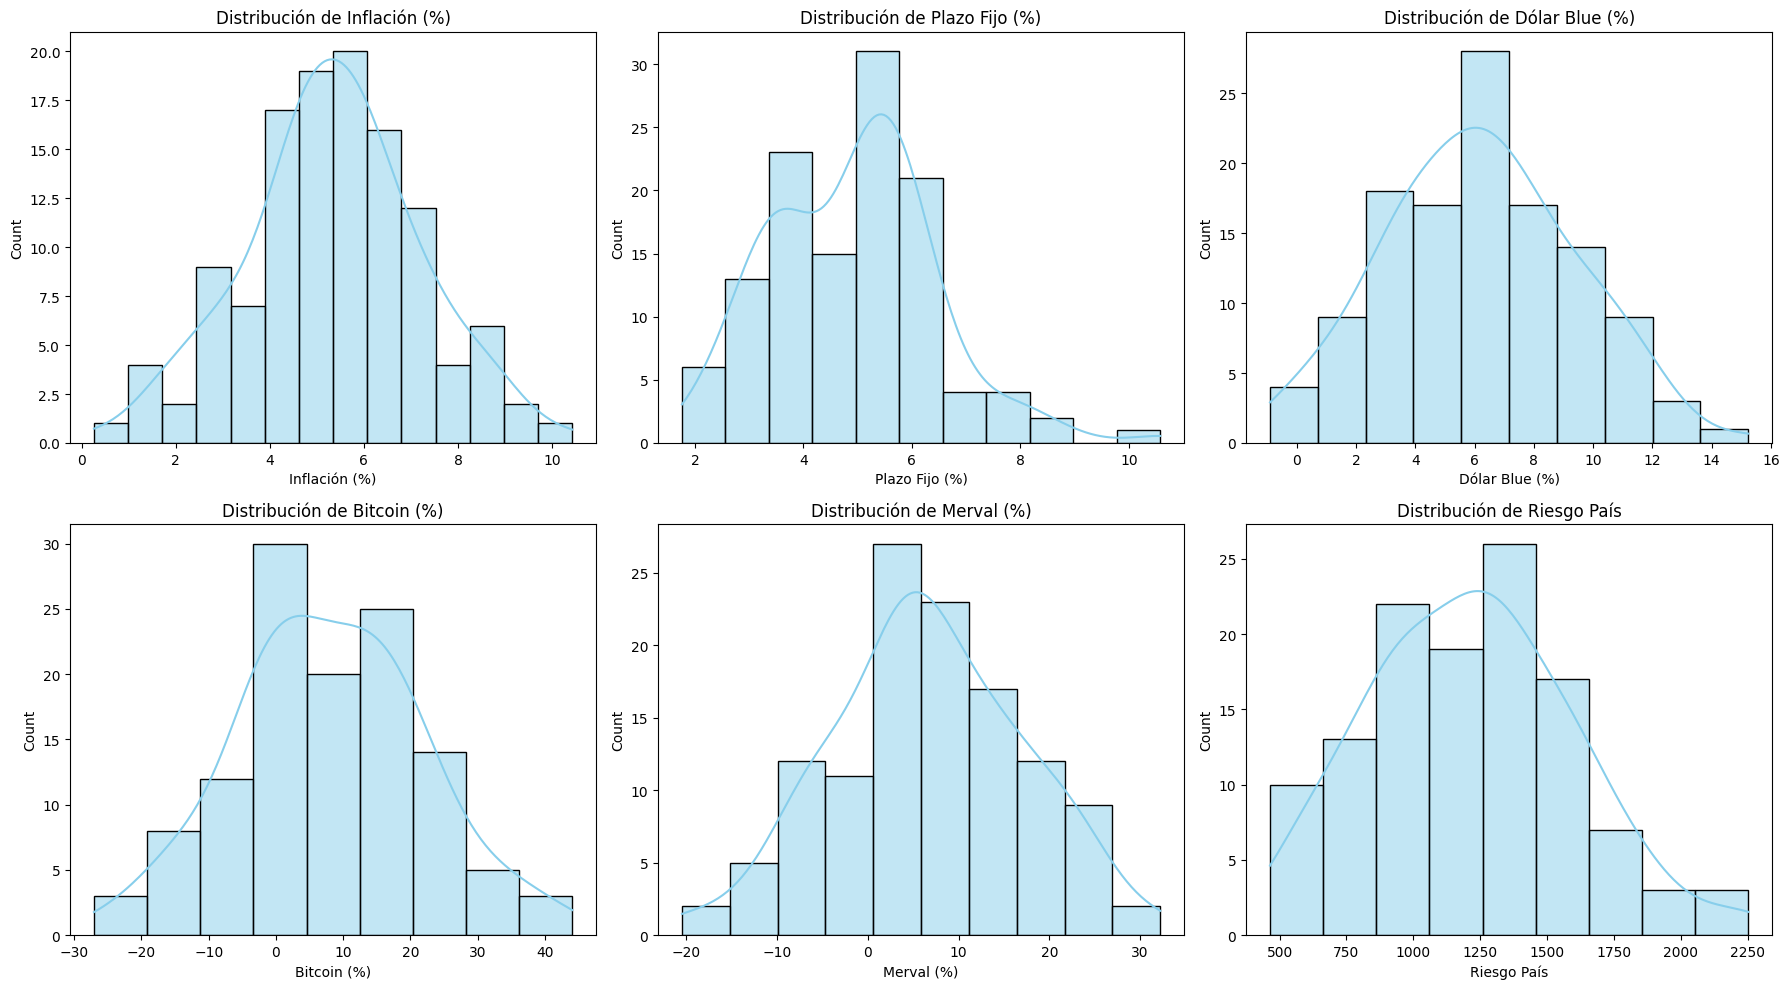

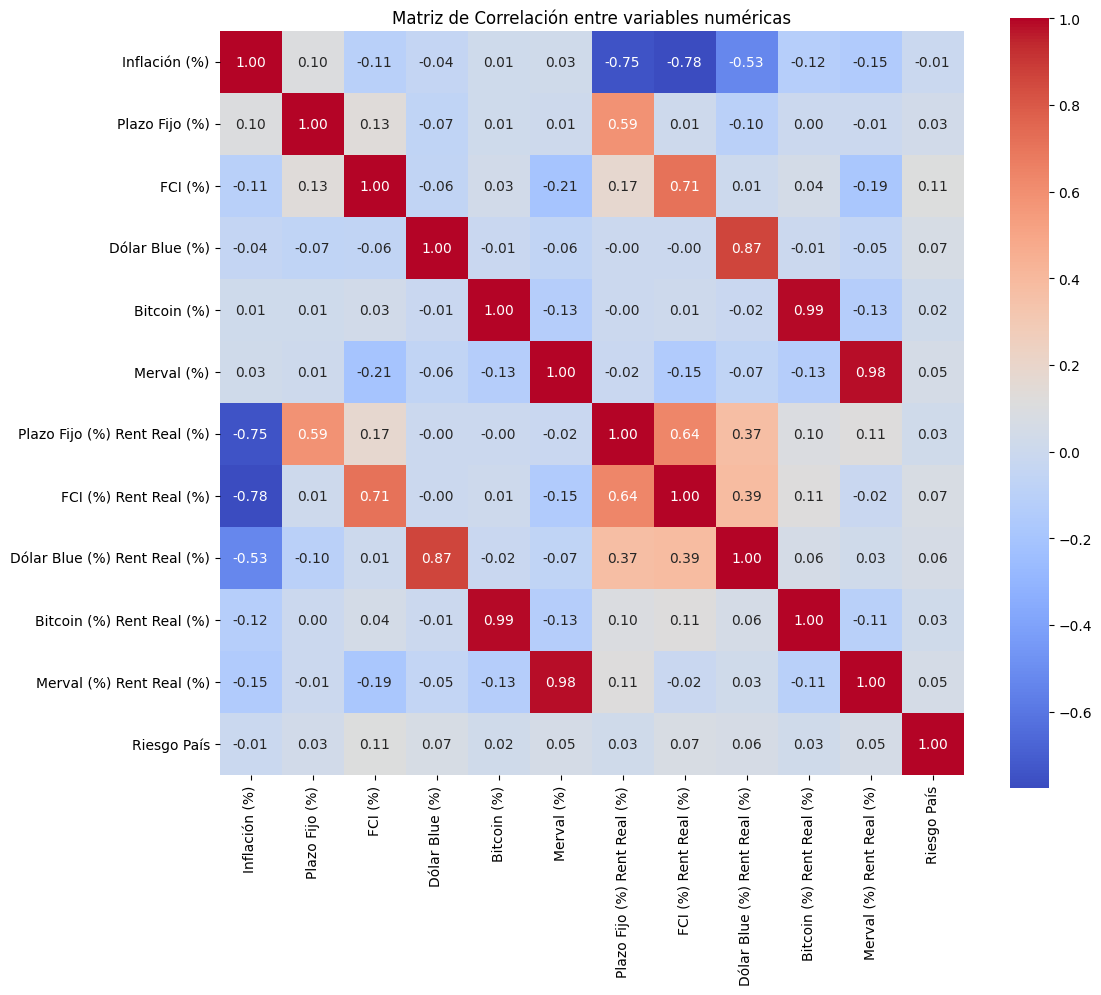

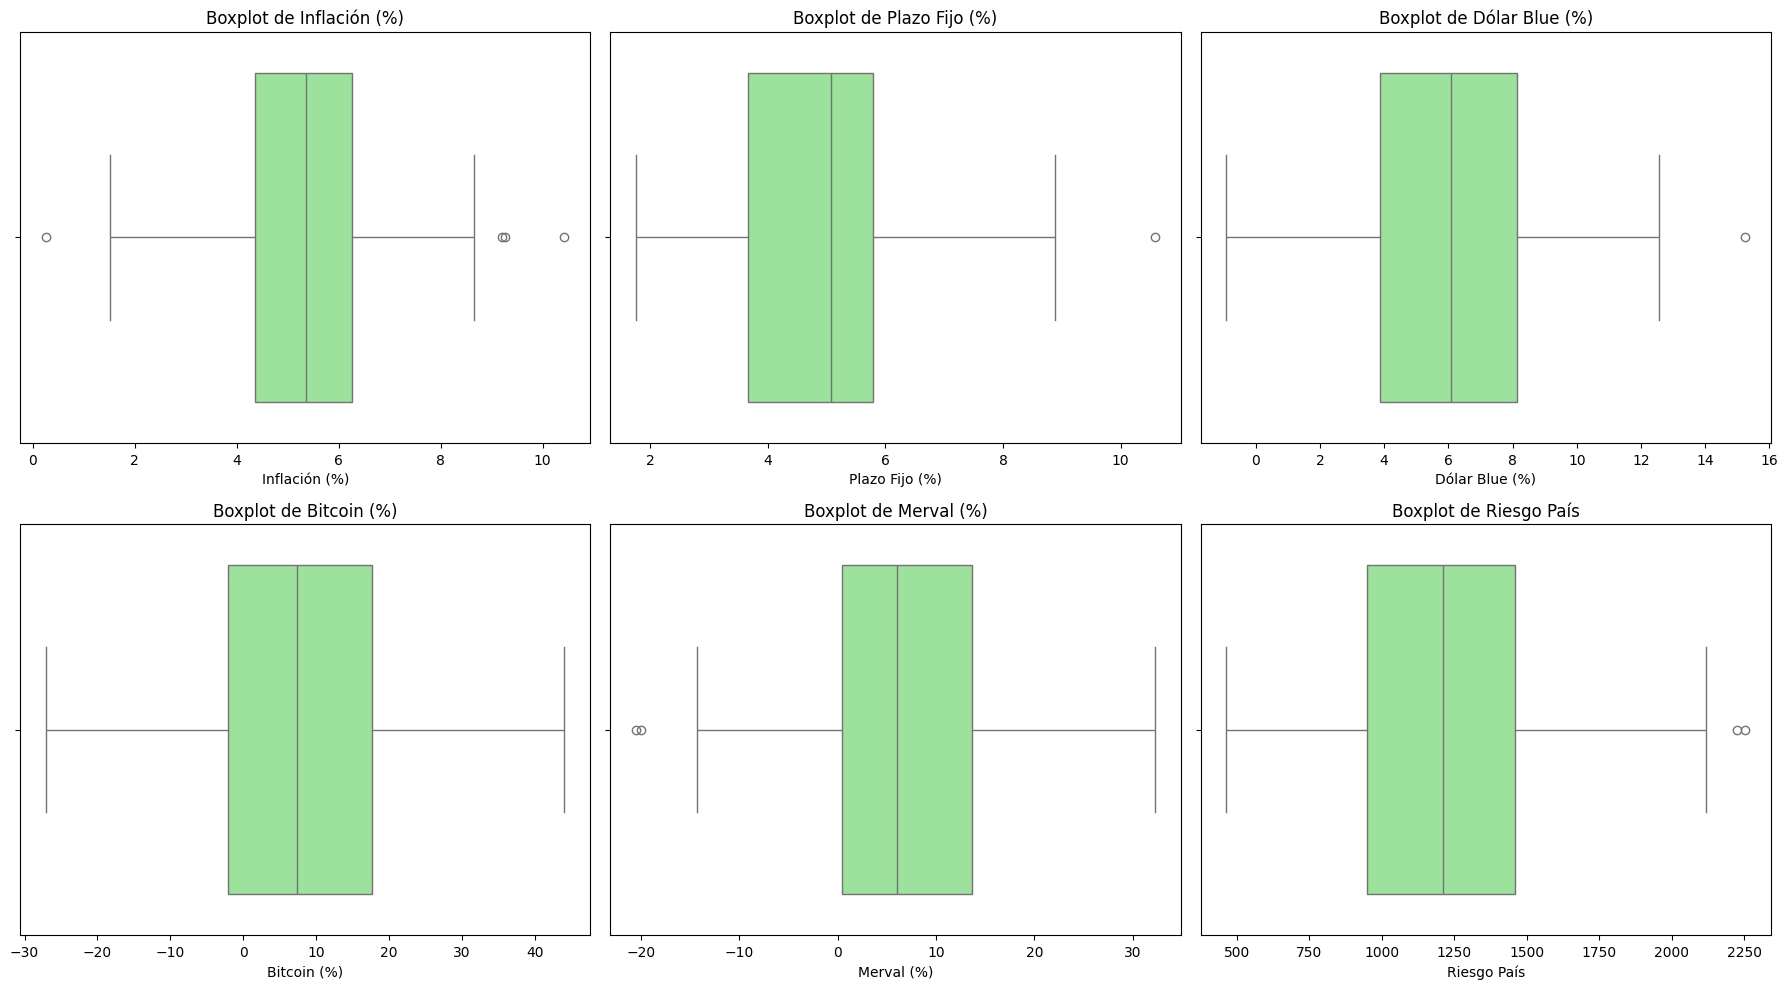

In [52]:
#1 Información general y tipos de datos
print("Información del dataframe:")
print(df.info())

#2 Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())

#3 Valores faltantes por columna
print("\nValores faltantes por columna:")
print(df.isnull().sum())

#4 Histogramas para ver la distribución de los datos
fig, axes = plt.subplots(2, 3, figsize=(18,10))
cols_hist = ['Inflación (%)', 'Plazo Fijo (%)', 'Dólar Blue (%)', 'Bitcoin (%)', 'Merval (%)', 'Riesgo País']
for i, col in enumerate(cols_hist):
    sns.histplot(df[col], kde=True, ax=axes[i//3, i%3], color='skyblue')
    axes[i//3, i%3].set_title(f'Distribución de {col}')
plt.tight_layout()
plt.show()

#5 Matriz de correlación
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12,10))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Matriz de Correlación entre variables numéricas')
plt.show()

#6 Boxplots para detectar outliers
fig, axes = plt.subplots(2, 3, figsize=(18,10))
for i, col in enumerate(cols_hist):
    sns.boxplot(x=df[col], ax=axes[i//3, i%3], color='lightgreen')
    axes[i//3, i%3].set_title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()



En esta sección se realizó un análisis exploratorio inicial del conjunto de datos. Primero, se examinaron las estadísticas descriptivas y la estructura del data frame, verificando que no existen valores nulos ni datos faltantes, lo que indica una base de datos limpia y lista para su uso.

A continuación, se generaron diferentes visualizaciones, como histogramas para analizar la distribución de las variables, boxplots para identificar posibles valores atípicos (outliers), y un mapa de calor (heat map) para observar correlaciones entre variables. Estos gráficos confirman que no se presentan outliers relevantes ni anomalías que puedan afectar el análisis posterior.

En conclusión, este análisis sugiere que los datos son confiables y adecuados para continuar con el modelado y análisis.


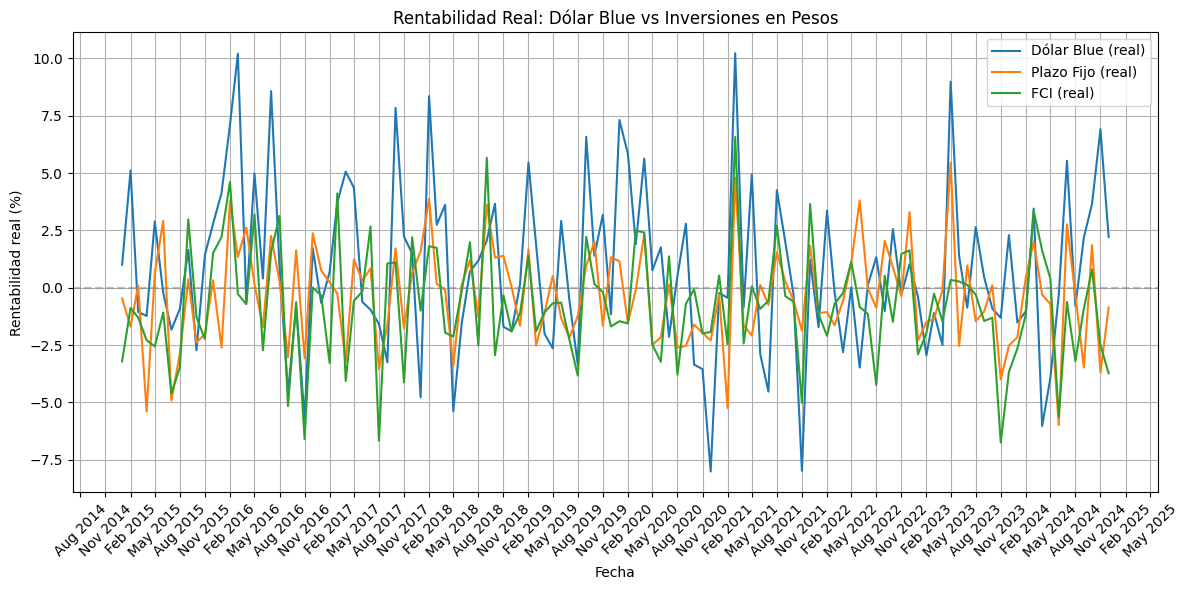

In [53]:
# Gráfico de Dolar Blue vs Inversiones en Pesos
plt.figure(figsize=(12,6))
plt.plot(df['Fecha'], df['Dólar Blue (%) Rent Real (%)'], label='Dólar Blue (real)')
plt.plot(df['Fecha'], df['Plazo Fijo (%) Rent Real (%)'], label='Plazo Fijo (real)')
plt.plot(df['Fecha'], df['FCI (%) Rent Real (%)'], label='FCI (real)')

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('Rentabilidad Real: Dólar Blue vs Inversiones en Pesos')
plt.xlabel('Fecha')
plt.ylabel('Rentabilidad real (%)')
plt.legend()
plt.grid(True)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



Este gráfico compara la rentabilidad real del dólar blue con la de las inversiones en pesos, específicamente plazo fijo y fondos comunes de inversión (FCI). Se observa que el dólar blue sigue una tendencia similar a las inversiones en pesos, pero con una mayor volatilidad.

En particular, cuando la rentabilidad es positiva, el dólar blue tiende a superar a las inversiones en pesos, y cuando es negativa, su rentabilidad suele caer por debajo de la de estas inversiones. Es decir, el dólar blue oscila en rangos más amplios, mostrando picos más altos y caídas más profundas.

En los últimos meses, se nota un aumento significativo en la rentabilidad del dólar blue mientras que la rentabilidad de las inversiones en pesos disminuye, lo que indica que, en este período, el dólar blue ha sido más rentable.

Sin embargo, dado que el dólar blue presenta mayor volatilidad y riesgo de pérdidas en períodos negativos, conviene evaluar cuidadosamente el momento de comprar y vender. Fuera eso, es mas rentable invertir el dinero en dolar blue que en inversiones en pesos.

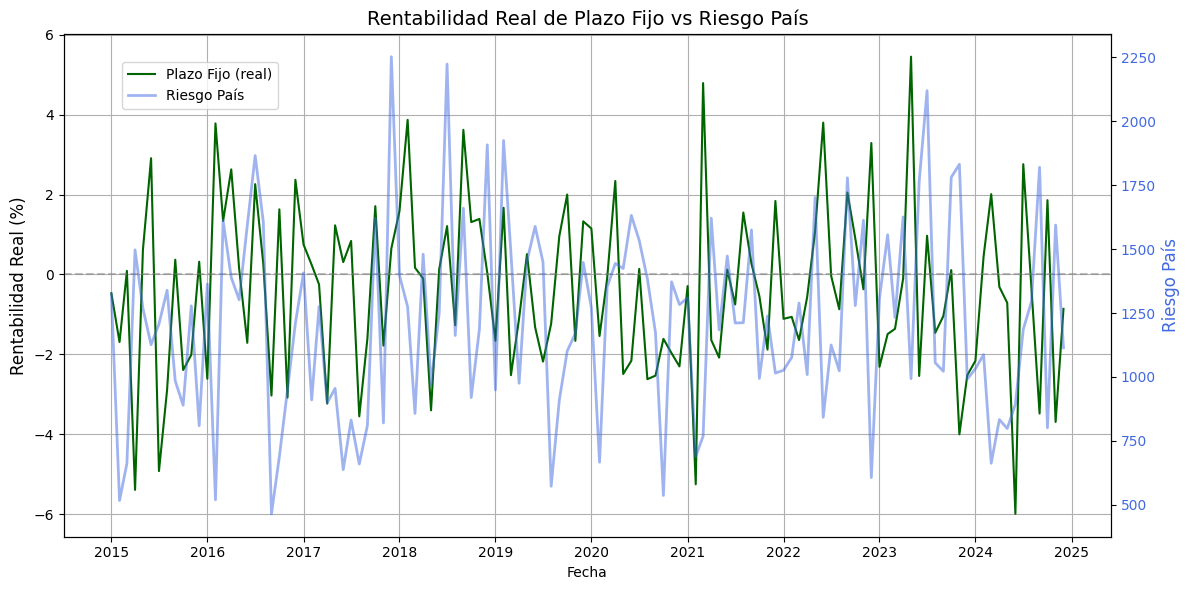

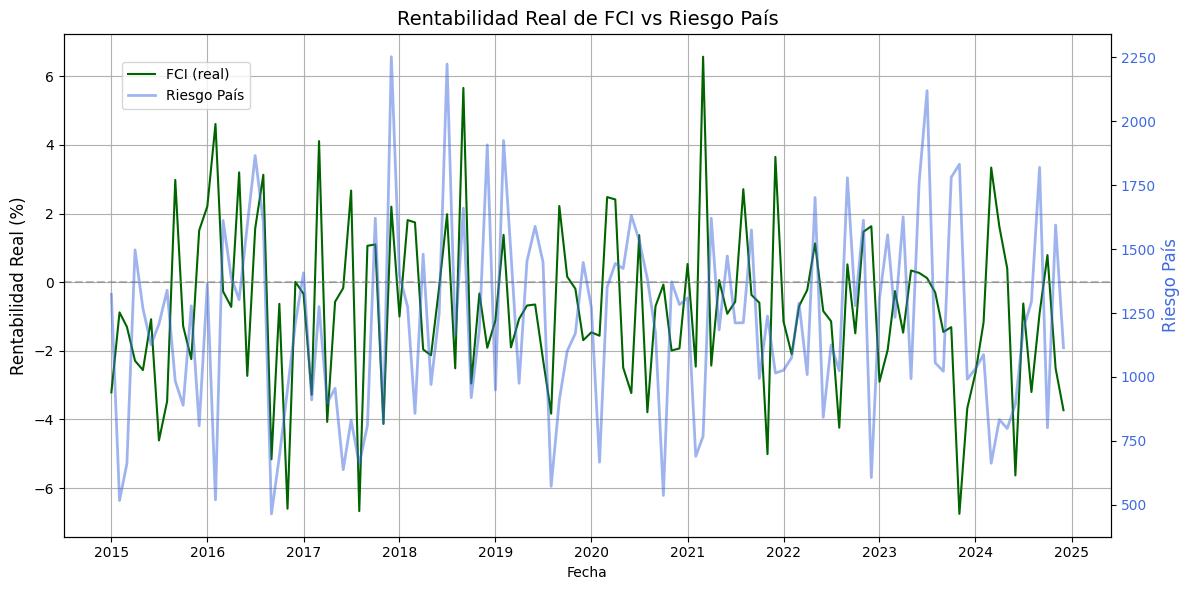

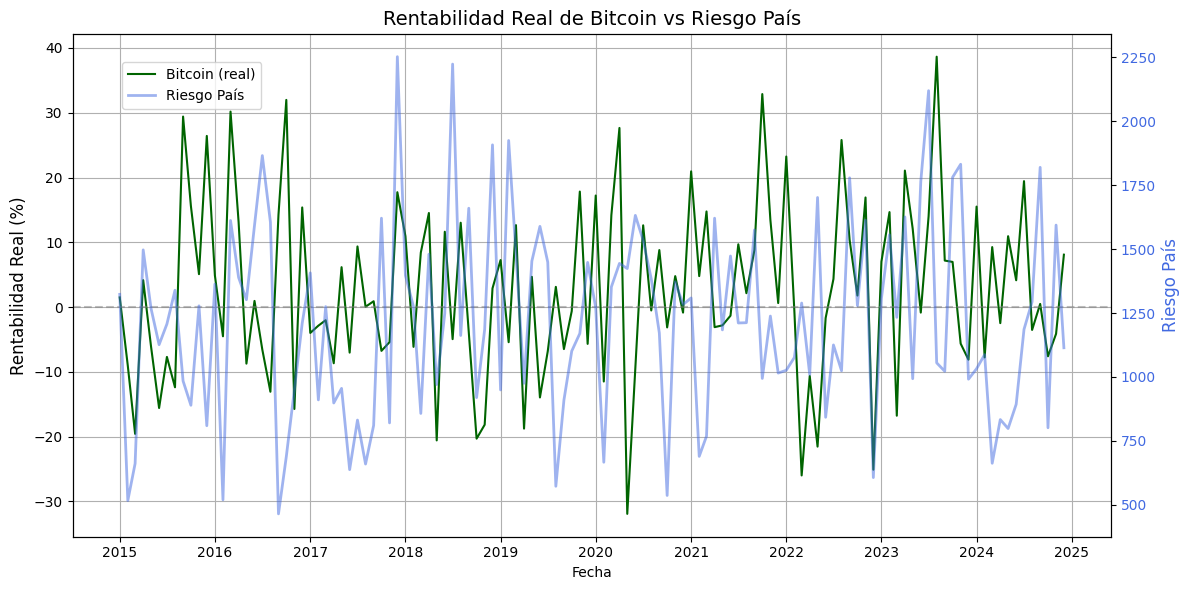

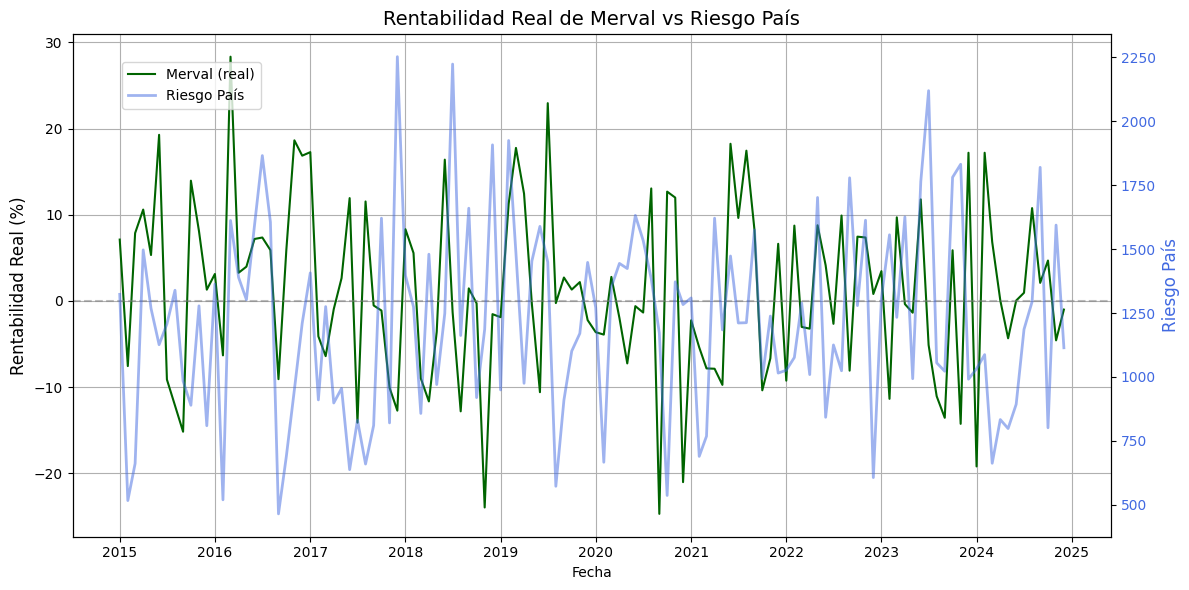

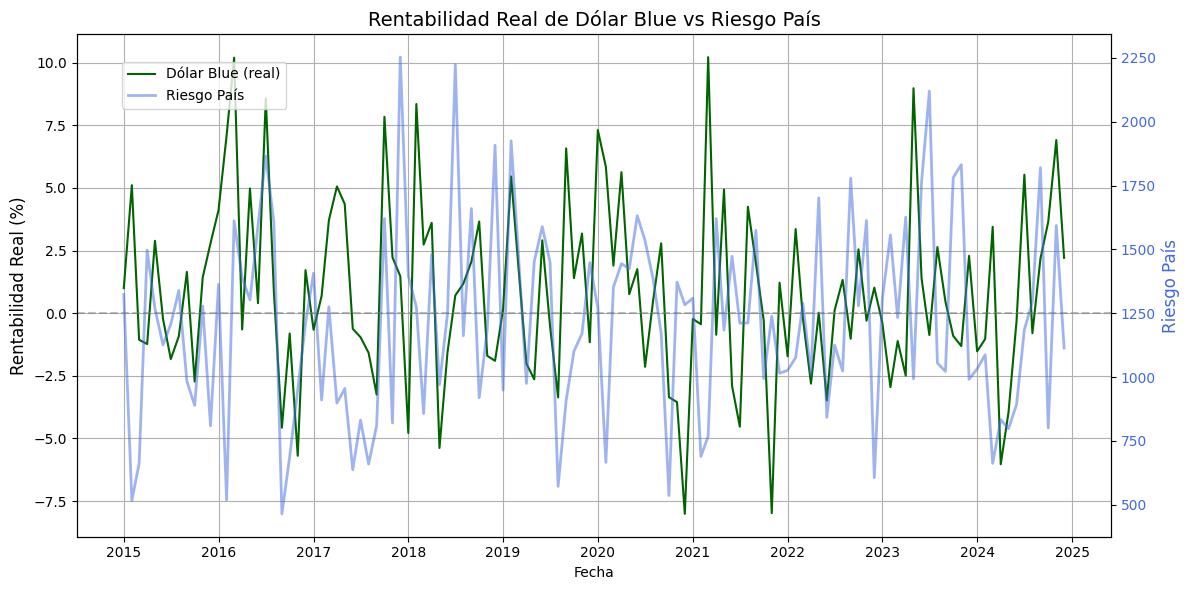

In [54]:
# Lista de inversiones a graficar
inversiones = [
    ('Plazo Fijo (%) Rent Real (%)', 'Plazo Fijo'),
    ('FCI (%) Rent Real (%)', 'FCI'),
    ('Bitcoin (%) Rent Real (%)', 'Bitcoin'),
    ('Merval (%) Rent Real (%)', 'Merval'),
    ('Dólar Blue (%) Rent Real (%)', 'Dólar Blue'),
]

#A cada inversión la comparo con el riesgo pais

for col, nombre in inversiones:
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(df['Fecha'], df[col], label=f'{nombre} (real)', color='darkgreen', linewidth=1.5)
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)

    ax1.set_ylabel('Rentabilidad Real (%)', fontsize=12)
    ax1.set_xlabel('Fecha')
    ax1.grid(True)
    ax2 = ax1.twinx()
    ax2.plot(df['Fecha'], df['Riesgo País'], label='Riesgo País', color='royalblue', alpha=0.5, linewidth=2)
    ax2.set_ylabel('Riesgo País', fontsize=12, color='royalblue')
    ax2.tick_params(axis='y', labelcolor='royalblue')
    ax1.xaxis.set_major_locator(mdates.YearLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.xticks(rotation=45)
    plt.title(f'Rentabilidad Real de {nombre} vs Riesgo País', fontsize=14)
    fig.tight_layout()
    fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
    plt.show()


A partir de los gráficos no se puede concluir una tendencia específica y constante entre el riesgo país y la rentabilidad de cada inversión. Sin embargo, se pueden observan ciertos patrones:

Las inversiones en pesos, como el Plazo Fijo y los FCI, tienden a seguir la tendencia del riesgo país. Es decir, cuando el riesgo país aumenta, estas inversiones también suelen mostrar una mayor rentabilidad. Esto podría deberse a que, ante mayor incertidumbre, los instrumentos locales ajustan sus tasas para seguir siendo atractivos.

El dólar blue aparece como el activo más sensible y beneficiado por la suba del riesgo país. Cada vez que el riesgo país se dispara, el valor del dólar informal también lo hace, lo cual refleja cómo este activo actúa como refugio en contextos de crisis o desconfianza económica.

En cuanto a los activos internacionales o dolarizados, como el Bitcoin o los Cedears (acciones extranjeras que cotizan en Argentina), no se puede establecer una relación directa y constante con el riesgo país. Sin embargo, es importante remarcar que siempre van a resultar más convenientes en contextos donde Argentina pierde credibilidad o estabilidad económica, ya que no dependen exclusivamente del contexto local.

En conclusión, si bien no se observa una relación definida entre el riesgo país y todos los activos, los gráficos apoyan la hipótesis de que durante períodos de mayor riesgo país, las inversiones en dólares o activos dolarizados (como Cedears o BTC) tienden a rendir mejor, especialmente frente a la caída de confianza en activos nacionales.



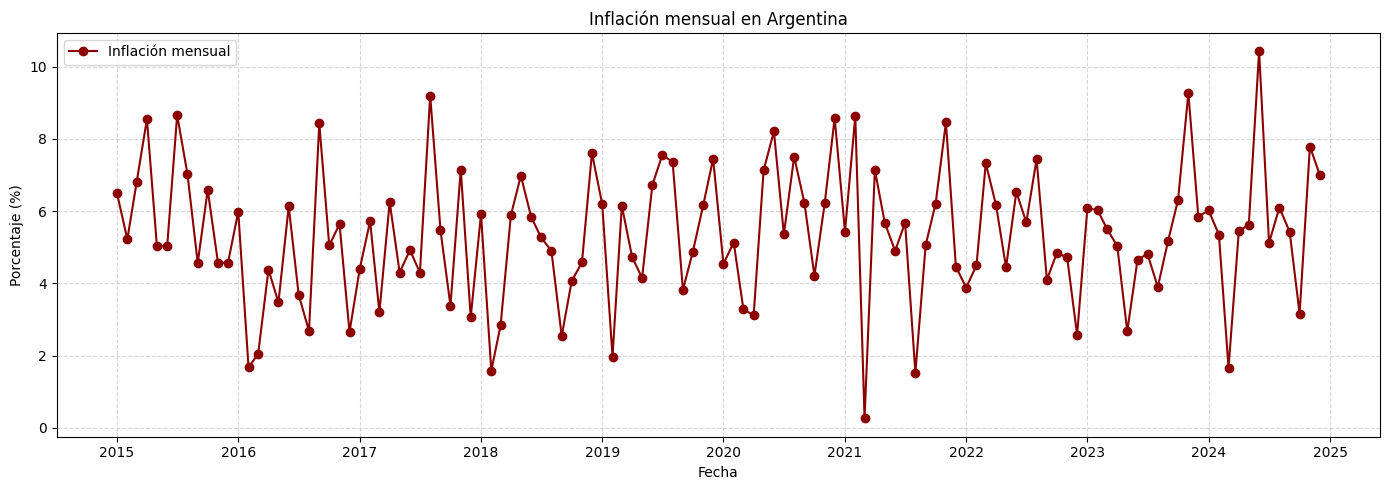

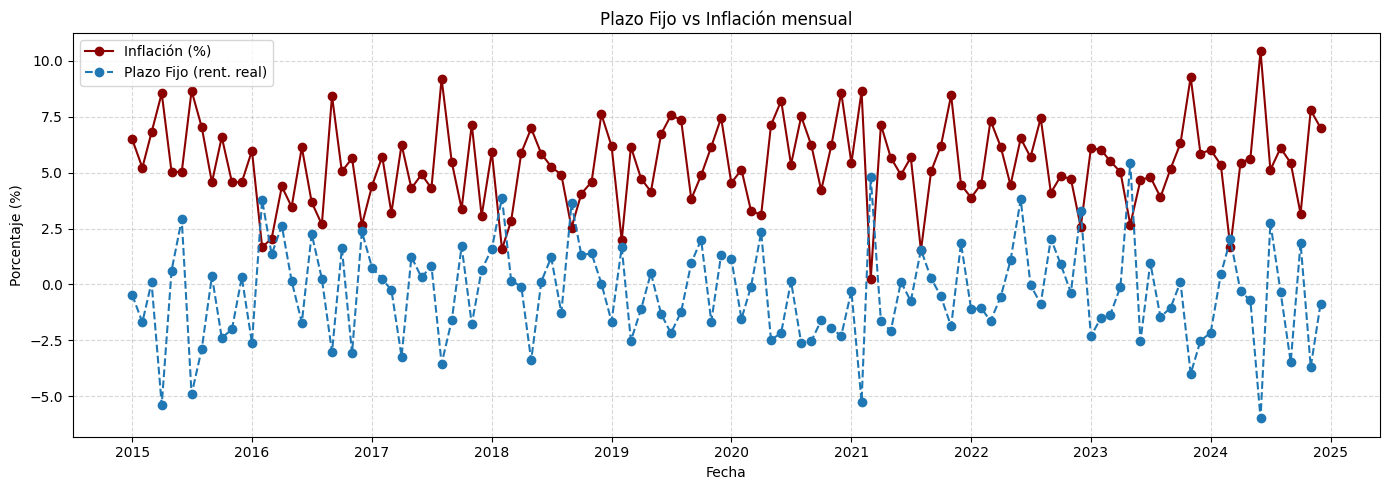

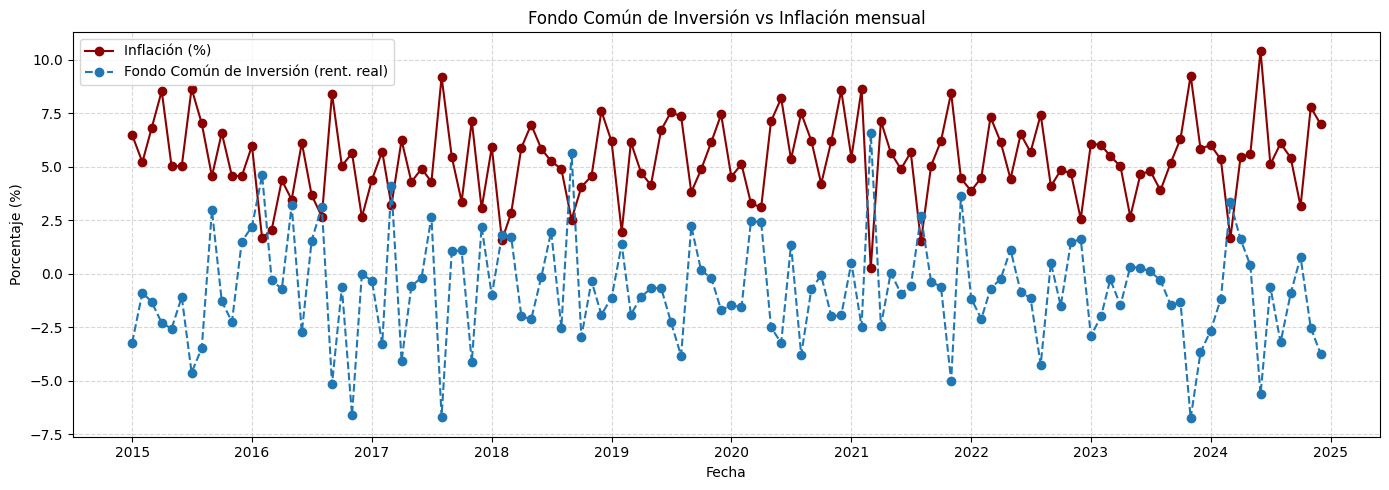

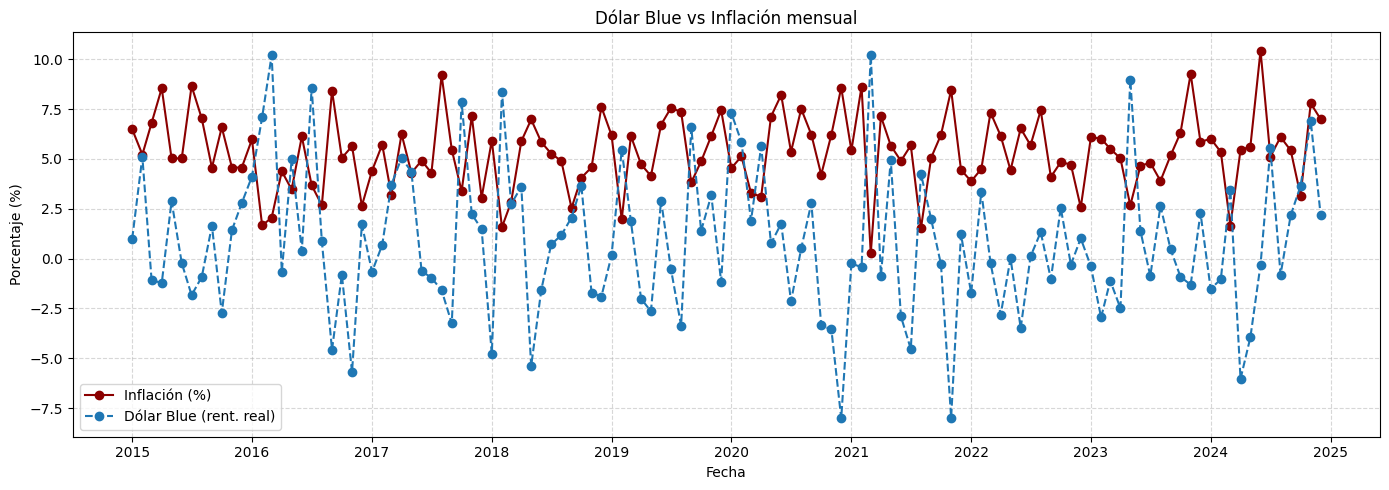

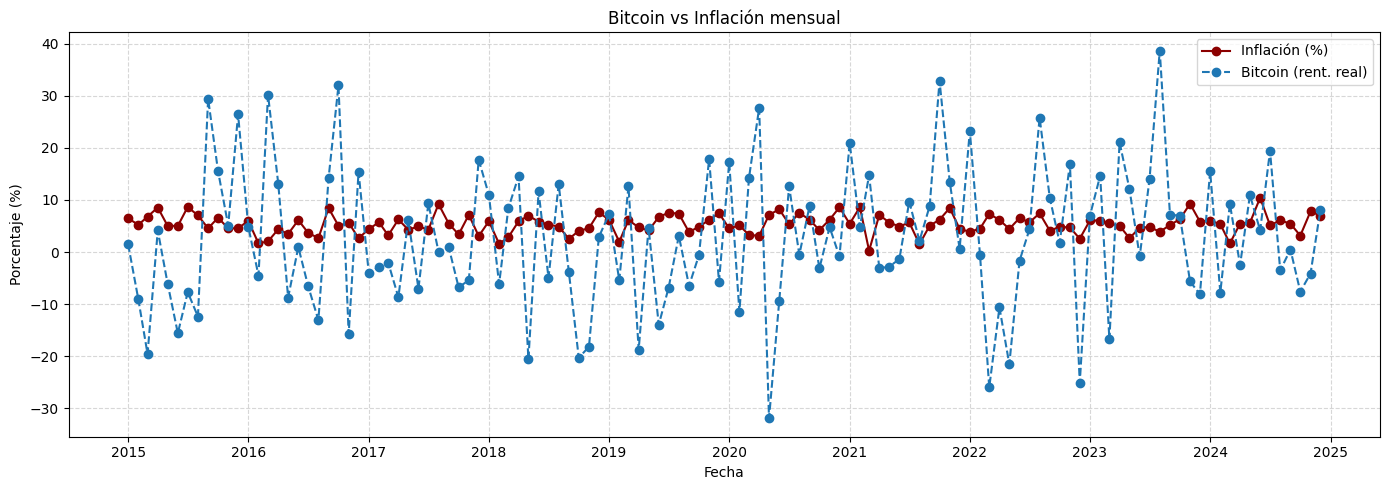

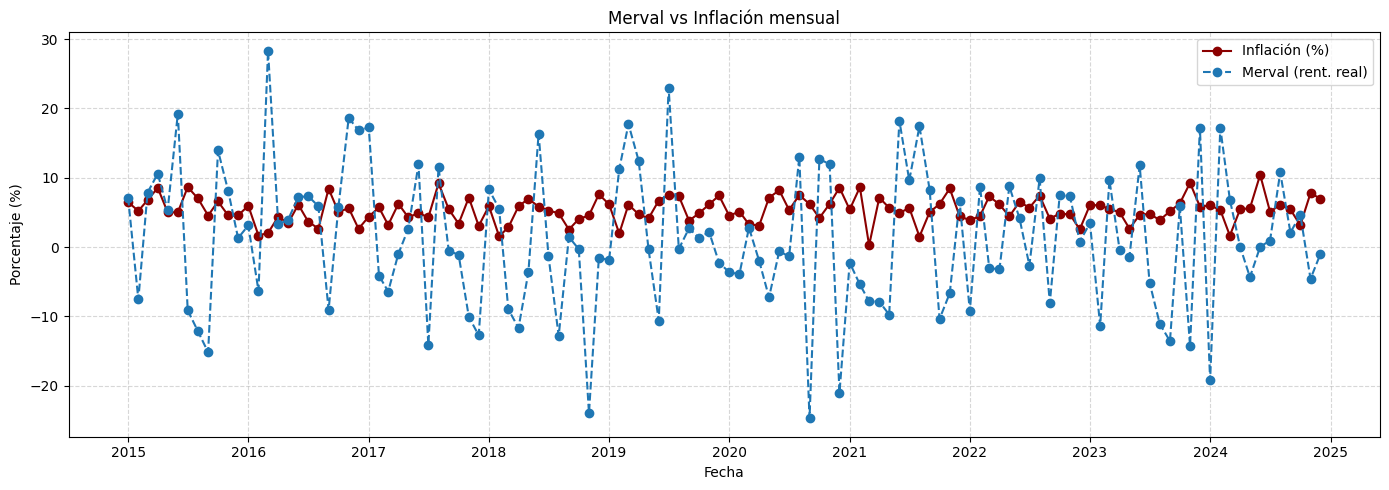

In [55]:
# Gráfico de Inflación mensual con puntos
plt.figure(figsize=(14,5))
plt.plot(df['Fecha'], df['Inflación (%)'], color='darkred', label='Inflación mensual', marker='o')
plt.title('Inflación mensual en Argentina')
plt.xlabel('Fecha')
plt.ylabel('Porcentaje (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Grafico de Inflación vs Inversiones
def plot_inflacion_vs_inversion(nombre_columna, nombre_legible):
    plt.figure(figsize=(14,5))
    plt.plot(df['Fecha'], df['Inflación (%)'], label='Inflación (%)', color='darkred', marker='o')
    plt.plot(df['Fecha'], df[nombre_columna], label=f'{nombre_legible} (rent. real)', marker='o', linestyle='--')
    plt.title(f'{nombre_legible} vs Inflación mensual')
    plt.xlabel('Fecha')
    plt.ylabel('Porcentaje (%)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_inflacion_vs_inversion('Plazo Fijo (%) Rent Real (%)', 'Plazo Fijo')
plot_inflacion_vs_inversion('FCI (%) Rent Real (%)', 'Fondo Común de Inversión')
plot_inflacion_vs_inversion('Dólar Blue (%) Rent Real (%)', 'Dólar Blue')
plot_inflacion_vs_inversion('Bitcoin (%) Rent Real (%)', 'Bitcoin')
plot_inflacion_vs_inversion('Merval (%) Rent Real (%)', 'Merval')


Estos gráficos muestran la relación entre la inflación mensual en Argentina y las distintas inversiones que estuvimos investigando.
Está bastante claro que se puede afirmar nuestra hipótesis: la rentabilidad real de las acciones nacionales en muy pocas ocasiones logra superar a la inflación mensual. En cambio, la rentabilidad de las inversiones internacionales, como el Bitcoin y el Merval, suele superar con mayor frecuencia a la inflación.
Por lo tanto, podemos afirmar nuestra hipótesis.



In [56]:
#Modelado, entrenamiento y prediccion de un modelo de clasificación binaria para predecir si una inversion va a superar la inflación o no

df = df.sort_values('Fecha').reset_index(drop=True)
df.set_index('Fecha', inplace=True)

inversiones = [
    "Plazo Fijo (%) Rent Real (%)",
    "FCI (%) Rent Real (%)",
    "Dólar Blue (%) Rent Real (%)",
    "Bitcoin (%) Rent Real (%)",
    "Merval (%) Rent Real (%)",
]
#
# Lags
for inversion in inversiones:
    df[f"{inversion}_lag1"] = df[inversion].shift(1)
    df[f"{inversion}_lag2"] = df[inversion].shift(2)
    df[f"{inversion}_lag3"] = df[inversion].shift(3)

# Diferencias porcentuales
variables_to_diff = [
    "Inflación (%)",
    "Riesgo País"
] + inversiones

for col in variables_to_diff:
    if col in df.columns:
        df[f"{col}_mom"] = df[col].pct_change() * 100

# Medias móviles, volatilidad y tendencias
for inversion in inversiones:
    df[f"{inversion}_ma3"] = df[inversion].rolling(3).mean()
    df[f"{inversion}_ma6"] = df[inversion].rolling(6).mean()
    df[f"{inversion}_vol3"] = df[inversion].rolling(3).std()
    df[f"{inversion}_vol6"] = df[inversion].rolling(6).std()
    df[f"{inversion}_trend3"] = df[inversion] - df[f"{inversion}_ma3"]
    df[f"{inversion}_trend6"] = df[inversion] - df[f"{inversion}_ma6"]

# Interacciones
df["Merval_vs_Blue"] = df["Merval (%) Rent Real (%)"] - df["Dólar Blue (%) Rent Real (%)"]
df["Bitcoin_vs_Blue"] = df["Bitcoin (%) Rent Real (%)"] - df["Dólar Blue (%) Rent Real (%)"]
df["FCI_vs_PlazoFijo"] = df["FCI (%) Rent Real (%)"] - df["Plazo Fijo (%) Rent Real (%)"]

df.dropna(inplace=True)

# Modelado para cada inversión
#Fue usado Random Forest Classifier y GridSearchCV para optimizar el modelo y tener las respuestas más confiables y no tener ningún problema.
for inversion in inversiones:
    print(f"\n=== Modelando para inversión: {inversion} ===")

    target_name = f"supera_inflacion_{inversion}"
    df[target_name] = (df[inversion] > 0).astype(int)

    features = df.drop(columns=[target_name])
    target = df[target_name]

    X_train, X_test, y_train, y_test = train_test_split(
        features, target, test_size=0.2, random_state=42, stratify=target
    )

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
    ])

    param_grid = {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [5, 10, None],
        'clf__min_samples_split': [2, 5],
    }

    grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    class_index_1 = list(best_model.named_steps['clf'].classes_).index(1)
    y_proba = best_model.predict_proba(X_test)[:, class_index_1]

    # Buscar el umbral óptimo
    best_threshold = 0
    best_f1 = 0
    for threshold in np.arange(0, 1.01, 0.05):
        y_pred_thresh = (y_proba >= threshold).astype(int)
        _, _, f1, _ = precision_recall_fscore_support(y_test, y_pred_thresh, average='binary', zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold

    print(f"Umbral óptimo para F1: {best_threshold:.2f} con F1: {best_f1:.4f}")
    print("Reporte clasificación:")
    print(classification_report(y_test, (y_proba >= best_threshold).astype(int), zero_division=0))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, (y_proba >= best_threshold).astype(int)))
    print(f"ROC AUC en test: {roc_auc_score(y_test, y_proba):.4f}")

    # Predicción para el próximo mes
    last_date = df.index.max()
    next_month = last_date + DateOffset(months=1)
    df_next = pd.DataFrame(index=[next_month])
    try:
        df_next[f"{inversion}_lag1"] = df[inversion].loc[last_date]
        df_next[f"{inversion}_lag2"] = df[inversion].loc[last_date - DateOffset(months=1)]
        df_next[f"{inversion}_lag3"] = df[inversion].loc[last_date - DateOffset(months=2)]
    except KeyError:
        print("No hay datos suficientes para calcular lags.")
        continue
    for col in variables_to_diff:
        try:
            df_next[f"{col}_mom"] = (df[col].loc[last_date] - df[col].loc[last_date - DateOffset(months=1)]) / df[col].loc[last_date - DateOffset(months=1)] * 100
        except:
            df_next[f"{col}_mom"] = 0
    for window in [3, 6]:
        df_next[f"{inversion}_ma{window}"] = df[inversion].rolling(window).mean().loc[last_date]
        df_next[f"{inversion}_vol{window}"] = df[inversion].rolling(window).std().loc[last_date]

    df_next[f"{inversion}_trend3"] = df_next[f"{inversion}_lag1"] - df_next[f"{inversion}_ma3"]
    df_next[f"{inversion}_trend6"] = df_next[f"{inversion}_lag1"] - df_next[f"{inversion}_ma6"]
    df_next["Merval_vs_Blue"] = df["Merval (%) Rent Real (%)"].loc[last_date] - df["Dólar Blue (%) Rent Real (%)"].loc[last_date]
    df_next["Bitcoin_vs_Blue"] = df["Bitcoin (%) Rent Real (%)"].loc[last_date] - df["Dólar Blue (%) Rent Real (%)"].loc[last_date]
    df_next["FCI_vs_PlazoFijo"] = df["FCI (%) Rent Real (%)"].loc[last_date] - df["Plazo Fijo (%) Rent Real (%)"].loc[last_date]

# Agregar columnas faltantes
    for col in features.columns:
        if col not in df_next.columns:
            df_next[col] = 0

    df_next = df_next[features.columns]
    y_proba_next = best_model.predict_proba(df_next)[:, class_index_1]
    y_pred_next = (y_proba_next >= best_threshold).astype(int)

    print(f"\nPredicción para el próximo mes ({next_month.strftime('%Y-%m')}):")
    print(f"Probabilidad de superar inflación: {y_proba_next[0]:.4f}")
    print(f"Predicción (1 = supera inflación, 0 = no): {y_pred_next[0]}")



=== Modelando para inversión: Plazo Fijo (%) Rent Real (%) ===
Umbral óptimo para F1: 0.30 con F1: 1.0000
Reporte clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        10

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23

Matriz de confusión:
[[13  0]
 [ 0 10]]
ROC AUC en test: 1.0000

Predicción para el próximo mes (2025-01):
Probabilidad de superar inflación: 0.3316
Predicción (1 = supera inflación, 0 = no): 1

=== Modelando para inversión: FCI (%) Rent Real (%) ===
Umbral óptimo para F1: 0.30 con F1: 1.0000
Reporte clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00         8

    accuracy                           1.00        23
   macro

En este bloque de código modelamos y entrenamos modelos de Machine Learning para intentar predecir si una inversión va a superar la inflación el mes siguiente. El objetivo es demostrar que, a partir de datos históricos, es posible predecir si una operación superará a la inflación el próximo mes.

Los resultados muestran que los parámetros de evaluación son óptimos, lo cual indica que el modelo no presentó errores durante el procesamiento. Sin embargo, esto no significa que la predicción sea 100% confiable.

El F1-score fue igual a 1 en todos los casos, lo que significa que el modelo clasificó perfectamente todas las muestras del conjunto de prueba. Esto podría deberse al tamaño reducido del dataset, pero no representa un problema ya que el modelo cumple con el objetivo planteado.

Por lo tanto, nuestra hipótesis es cierta. Es posible, mediante un modelado óptimo con Machine Learning, predecir si una inversión superará a la inflación o no.


In [57]:
# Modelado de regresión para cada inversión
for inversion in inversiones:
    print(f"\n=== Modelando regresión para inversión: {inversion} ===")

    target = df[inversion]

    # Sacamos columnas de targets binarios
    binary_targets = [f"supera_inflacion_{inv}" for inv in inversiones if f"supera_inflacion_{inv}" in df.columns]
    drop_cols = inversiones + binary_targets
    features = df.drop(columns=drop_cols)

    X_train, X_test, y_train, y_test = train_test_split(
        features, target, test_size=0.2, random_state=42
    )

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('reg', RandomForestRegressor(random_state=42))
    ])

    param_grid = {
        'reg__n_estimators': [100, 200],
        'reg__max_depth': [5, 10, None],
        'reg__min_samples_split': [2, 5],
    }

    grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_

    print(f"Mejor score en CV (neg MAE): {grid_search.best_score_:.4f}")
    print(f"Mejores parámetros: {grid_search.best_params_}")

    y_pred = best_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE en test: {mae:.4f}")
    print(f"MSE en test: {mse:.4f}")
    print(f"R2 en test: {r2:.4f}")

    # Predicción próximo mes
    last_date = df.index.max()
    next_month = last_date + DateOffset(months=1)
    df_next = pd.DataFrame(index=[next_month])

    for inversion_inner in inversiones:
        df_next[f"{inversion_inner}_lag1"] = df[inversion_inner].loc[last_date]
        df_next[f"{inversion_inner}_lag2"] = df[inversion_inner].loc[last_date - DateOffset(months=1)]
        df_next[f"{inversion_inner}_lag3"] = df[inversion_inner].loc[last_date - DateOffset(months=2)]

    for col in variables_to_diff:
        if col in df.columns:
            try:
                df_next[f"{col}_mom"] = (df[col].loc[last_date] - df[col].loc[last_date - DateOffset(months=1)]) / df[col].loc[last_date - DateOffset(months=1)] * 100
            except KeyError:
                df_next[f"{col}_mom"] = 0
        else:
            df_next[f"{col}_mom"] = 0

    for inversion_inner in inversiones:
        for window in [3, 6]:
            df_next[f"{inversion_inner}_ma{window}"] = df[inversion_inner].rolling(window).mean().loc[last_date]
            df_next[f"{inversion_inner}_vol{window}"] = df[inversion_inner].rolling(window).std().loc[last_date]

    for inversion_inner in inversiones:
        df_next[f"{inversion_inner}_trend3"] = df_next[f"{inversion_inner}_lag1"] - df_next[f"{inversion_inner}_ma3"]
        df_next[f"{inversion_inner}_trend6"] = df_next[f"{inversion_inner}_lag1"] - df_next[f"{inversion_inner}_ma6"]

    df_next["Merval_vs_Blue"] = df["Merval (%) Rent Real (%)"].loc[last_date] - df["Dólar Blue (%) Rent Real (%)"].loc[last_date]
    df_next["Bitcoin_vs_Blue"] = df["Bitcoin (%) Rent Real (%)"].loc[last_date] - df["Dólar Blue (%) Rent Real (%)"].loc[last_date]
    df_next["FCI_vs_PlazoFijo"] = df["FCI (%) Rent Real (%)"].loc[last_date] - df["Plazo Fijo (%) Rent Real (%)"].loc[last_date]

    # Agregar columnas faltantes con 0
    for col in features.columns:
        if col not in df_next.columns:
            df_next[col] = 0

    X_next = df_next[features.columns]
    y_pred_next = best_model.predict(X_next)

    print(f"Predicción rentabilidad real próximo mes ({next_month.strftime('%Y-%m')}): {y_pred_next[0]:.4f}")


=== Modelando regresión para inversión: Plazo Fijo (%) Rent Real (%) ===
Mejor score en CV (neg MAE): -0.5852
Mejores parámetros: {'reg__max_depth': 5, 'reg__min_samples_split': 2, 'reg__n_estimators': 200}
MAE en test: 0.5894
MSE en test: 0.5163
R2 en test: 0.9030
Predicción rentabilidad real próximo mes (2025-01): -0.7732

=== Modelando regresión para inversión: FCI (%) Rent Real (%) ===
Mejor score en CV (neg MAE): -0.6879
Mejores parámetros: {'reg__max_depth': None, 'reg__min_samples_split': 2, 'reg__n_estimators': 100}
MAE en test: 0.6689
MSE en test: 0.9038
R2 en test: 0.8549
Predicción rentabilidad real próximo mes (2025-01): -3.2213

=== Modelando regresión para inversión: Dólar Blue (%) Rent Real (%) ===
Mejor score en CV (neg MAE): -1.0754
Mejores parámetros: {'reg__max_depth': 10, 'reg__min_samples_split': 5, 'reg__n_estimators': 100}
MAE en test: 1.0767
MSE en test: 2.1469
R2 en test: 0.8542
Predicción rentabilidad real próximo mes (2025-01): -1.7210

=== Modelando regresi

En esta sección modelamos, entrenamos y logramos predecir la rentabilidad real de cada inversión para el mes siguiente. Utilizamos un modelo de regresión basado en Random Forest y aplicamos Grid Search con validación cruzada para optimizar los hiperparámetros y obtener resultados confiables.

Se muestran todos los resultados de evalución y fueron optimos. Todos los modelos obtuvieron un coeficiente de determinación (R²) positivo y cercano a 1 en el conjunto de prueba, lo que indica que el modelo logra explicar gran parte de la variabilidad de los datos y que no se observaron anomalías significativas durante el análisis.

Por lo tanto, podemos concluir que, a partir de un buen modelado y procesamiento de datos históricos, es posible predecir la rentabilidad de un activo financiero en el mes siguiente con un buen nivel de precisión.